In [2]:
import pandas as pd
import pyarrow.parquet as pq
df = pd.read_parquet('Portscan-Friday-no-metadata.parquet')
print(df.head())

   Protocol  Flow Duration  Total Fwd Packets  Total Backward Packets  \
0         6        1266342                 41                      44   
1         6        1319353                 41                      44   
2         6            160                  1                       1   
3         6        1303488                 41                      42   
4         6             77                  1                       2   

   Fwd Packets Length Total  Bwd Packets Length Total  Fwd Packet Length Max  \
0                      2664                      6954                    456   
1                      2664                      6954                    456   
2                         0                         0                      0   
3                      2728                      6634                    456   
4                         0                         0                      0   

   Fwd Packet Length Min  Fwd Packet Length Mean  Fwd Packet Length Std  ...  \


In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

df = pd.read_parquet('Portscan-Friday-no-metadata.parquet')
print(df.duplicated().sum())
df = df.dropna()
X = df.drop('Label', axis=1)
y = df['Label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

0


In [4]:
dt_model = DecisionTreeClassifier(max_depth=3)
dt_model.fit(X_train, y_train)

dt_preds = dt_model.predict(X_test)

print("Decision Tree Metrics:")
print(f"Accuracy: {accuracy_score(y_test, dt_preds)}")
print(f"F1 Score: {f1_score(y_test, dt_preds, average='weighted')}")

Decision Tree Metrics:
Accuracy: 0.9925537551942438
F1 Score: 0.9914865708528195


In [5]:
rf_model = RandomForestClassifier(n_estimators=50)
rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)

print("Random Forest Metrics:")
print(f"Accuracy: {accuracy_score(y_test, rf_preds)}")
print(f"F1 Score: {f1_score(y_test, rf_preds, average='weighted')}")


















Random Forest Metrics:
Accuracy: 0.9997768915414006
F1 Score: 0.9997765118647224


Training Accuracy: 1.0
Testing Accuracy: 0.9997768915414006


<Axes: >

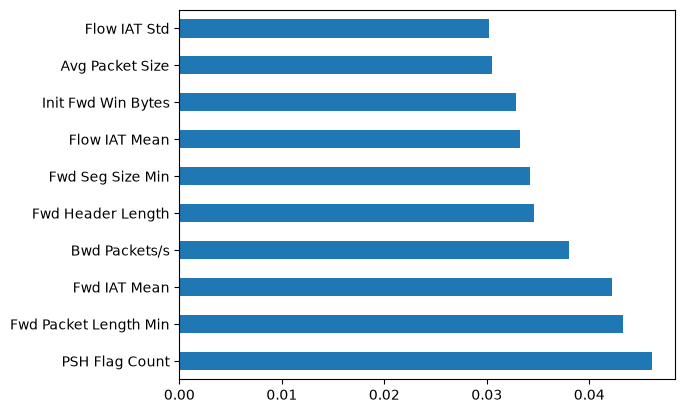

In [6]:
train_acc = rf_model.score(X_train, y_train)
test_acc = rf_model.score(X_test, y_test)

print(f"Training Accuracy: {train_acc}")
print(f"Testing Accuracy: {test_acc}")

importances = pd.Series(rf_model.feature_importances_, index=X.columns)
importances.nlargest(10).plot(kind='barh')

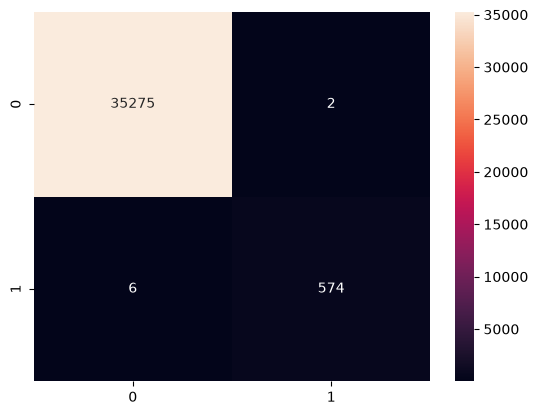

<Figure size 640x480 with 0 Axes>

In [17]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, rf_preds)
sns.heatmap(cm, annot=True, fmt='d')
plt.show()
plt.savefig('../results/heatmap.png')


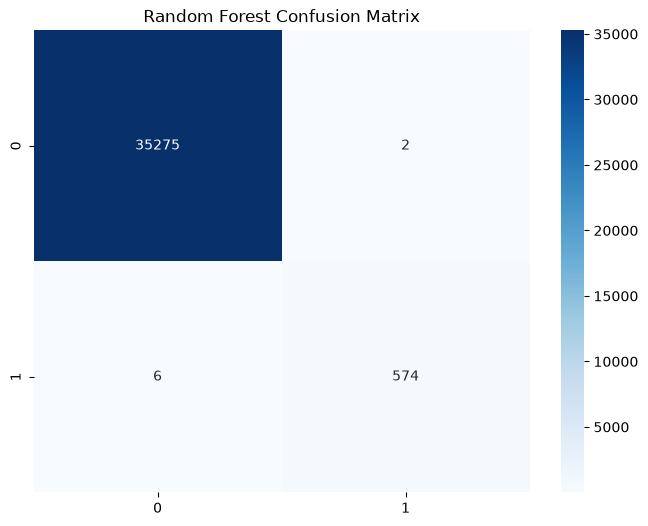

In [15]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

plt.figure(figsize=(8,6))
cm = confusion_matrix(y_test, rf_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Random Forest Confusion Matrix')
plt.savefig('../results/confusion_matrix.png')
plt.show()

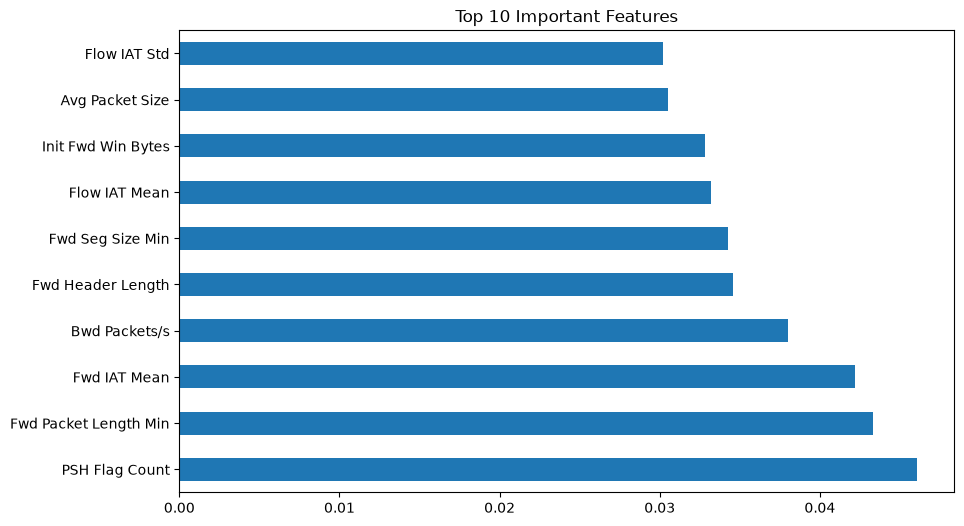

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

feature_imp = pd.Series(rf_model.feature_importances_, index=X.columns)
plt.figure(figsize=(10,6))
feature_imp.nlargest(10).plot(kind='barh')
plt.title('Top 10 Important Features')
plt.savefig('../results/feature_importance.png')
plt.show()